# Práctica No. 4 — API de Hilos
## Laboratorio de Sistemas Operativos
### Universidad de Antioquia — Ingeniería de Sistemas

### Integrantes:
- Santiago Villegas Narajango
- Ricardo Medina Herrera

---
# Análisis de ${\pi}$

## Evaluación  tiempo sin utilizar hilos

Se ejecutó `./pi_s 2000000000` para obtener el tiempo de referencia serial.

In [3]:
!gcc -o pi_s pi.c -lm

In [5]:
!./pi_s 2000000000

Pi aproximado: 3.141592653589839
Tiempo de ejecución: 9.187299 segundos


## Evaluación de tiempo utilizando hilos

Se ejecutó `./pi_p 2000000000 N` variando el número de hilos; el número N de hilos que se utilizaron fueron {1, 2, 4, 8, 16}


In [4]:
!gcc -o pi_p pi_p.c -lpthread -lm

In [13]:
!./pi_p 2000000000 1

Pi aproximado: 3.141592653589839
Número de hilos: 1
Tiempo de ejecución: 8.538579 segundos


In [11]:
!./pi_p 2000000000 2

Pi aproximado: 3.141592653589855
Número de hilos: 2
Tiempo de ejecución: 9.253971 segundos


In [14]:
!./pi_p 2000000000 4

Pi aproximado: 3.141592653589803
Número de hilos: 4
Tiempo de ejecución: 3.924200 segundos


In [15]:
!./pi_p 2000000000 8

Pi aproximado: 3.141592653589804
Número de hilos: 8
Tiempo de ejecución: 4.168248 segundos


In [16]:
!./pi_p 2000000000 16

Pi aproximado: 3.141592653589739
Número de hilos: 16
Tiempo de ejecución: 3.699857 segundos


## Tabla de Resultados

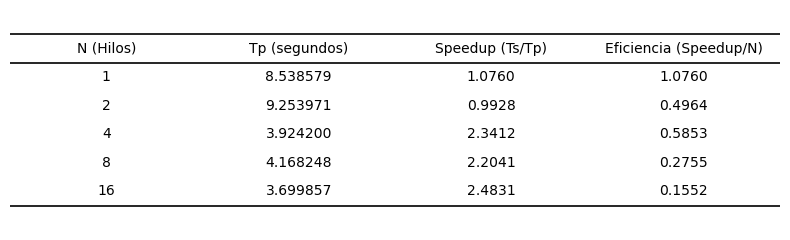

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

Ts = 9.187299

data = {
    'N (Hilos)': [1, 2, 4, 8, 16],
    'Tp (segundos)': [8.538579, 9.253971, 3.924200, 4.168248, 3.699857]
}

df = pd.DataFrame(data)
df['Speedup (Ts/Tp)'] = Ts / df['Tp (segundos)']
df['Eficiencia (Speedup/N)'] = df['Speedup (Ts/Tp)'] / df['N (Hilos)']

df_display = df.copy()
df_display['Tp (segundos)'] = df_display['Tp (segundos)'].map('{:.6f}'.format)
df_display['Speedup (Ts/Tp)'] = df_display['Speedup (Ts/Tp)'].map('{:.4f}'.format)
df_display['Eficiencia (Speedup/N)'] = df_display['Eficiencia (Speedup/N)'].map('{:.4f}'.format)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

nrows = len(df_display)

for (row, col), cell in table.get_celld().items():

    # Encabezado
    if row == 0:
        cell.visible_edges = 'TB'   # Top + Bottom
        cell.set_linewidth(1.2)

    # Última fila de datos
    elif row == nrows:
        cell.visible_edges = 'B'    # Solo Bottom
        cell.set_linewidth(1.2)

    # Filas intermedias
    else:
        cell.visible_edges = ''     # Sin bordes

plt.tight_layout()
plt.show()

## Gráfico de Speedup

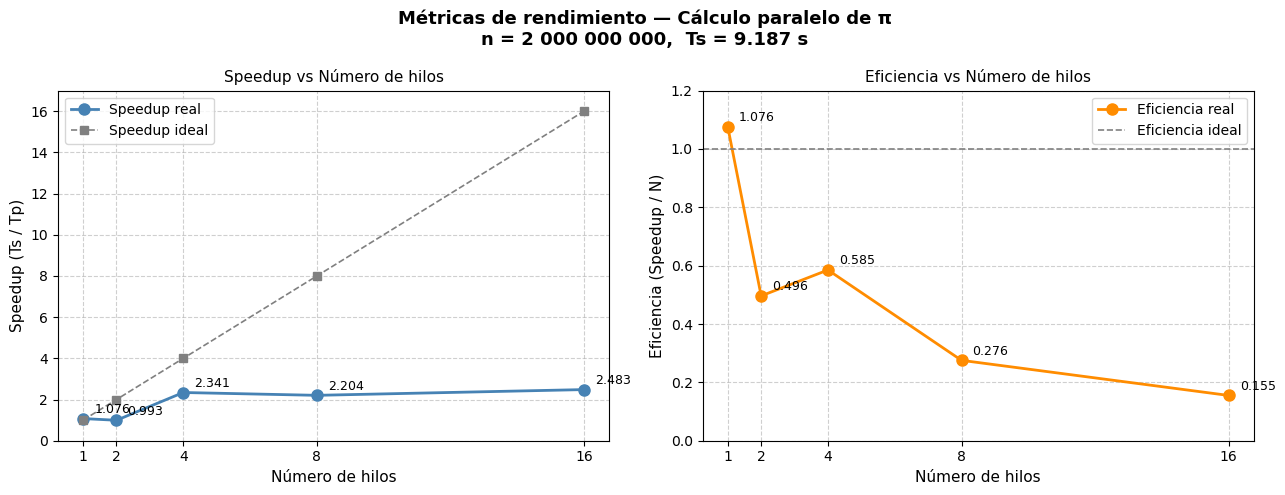

In [31]:
# =========================
# Gráficas de Speedup y Eficiencia
# =========================

threads = df['N (Hilos)'].values
speedup = df['Speedup (Ts/Tp)'].values
efic = df['Eficiencia (Speedup/N)'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    'Métricas de rendimiento — Cálculo paralelo de π\n'
    f'n = 2 000 000 000,  Ts = {Ts:.3f} s',
    fontsize=13,
    fontweight='bold'
)

# =========================
# Speedup
# =========================

ax1 = axes[0]

ax1.plot(
    threads,
    speedup,
    'o-',
    color='steelblue',
    linewidth=2,
    markersize=8,
    label='Speedup real'
)

# Línea ideal: Sp = p
ax1.plot(
    threads,
    threads,
    's--',
    color='gray',
    linewidth=1.2,
    markersize=6,
    label='Speedup ideal'
)

for x, y in zip(threads, speedup):
    ax1.annotate(
        f'{y:.3f}',
        (x, y),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

ax1.set_xlabel('Número de hilos', fontsize=11)
ax1.set_ylabel('Speedup (Ts / Tp)', fontsize=11)
ax1.set_title('Speedup vs Número de hilos', fontsize=11)

ax1.set_xticks(threads)

# Ajuste automático para que no se corte la línea ideal
ax1.set_ylim(0, max(threads) + 1)

ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# =========================
# Eficiencia
# =========================

ax2 = axes[1]

ax2.plot(
    threads,
    efic,
    'o-',
    color='darkorange',
    linewidth=2,
    markersize=8,
    label='Eficiencia real'
)

# Línea ideal: Ep = 1
ax2.axhline(
    y=1.0,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label='Eficiencia ideal'
)

for x, y in zip(threads, efic):
    ax2.annotate(
        f'{y:.3f}',
        (x, y),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

ax2.set_xlabel('Número de hilos', fontsize=11)
ax2.set_ylabel('Eficiencia (Speedup / N)', fontsize=11)
ax2.set_title('Eficiencia vs Número de hilos', fontsize=11)

ax2.set_xticks(threads)
ax2.set_ylim(0, 1.2)

ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()

# plt.savefig(
#     'speedup_eficiencia.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

# print('Figura guardada como speedup_eficiencia.png')

## Análisis de Resultados

### Comparación del rendimiento

Al comparar el tiempo de ejecución secuencial ($T_s = 9.187299$ s) con el tiempo obtenido por la versión paralela utilizando un único hilo ($T_p(1) = 8.538579$ s), se observa que la implementación paralela resulta ligeramente más rápida. Aunque ambos programas realizan esencialmente el mismo trabajo computacional, pequeñas diferencias pueden aparecer debido a factores como el estado de la memoria caché, la planificación de procesos del sistema operativo y las variaciones propias de cada medición.

Un resultado particular es que la ejecución con dos hilos ($T_p(2) = 9.253971$ s) presenta un tiempo mayor que el obtenido con un solo hilo. Este comportamiento puede explicarse porque el beneficio de dividir el trabajo entre dos hilos no logra compensar completamente los costos adicionales introducidos por la paralelización. Entre estos costos se encuentran la creación de los hilos, la sincronización mediante `pthread_join()`, la gestión realizada por el planificador del sistema operativo y la competencia por recursos compartidos como la memoria caché y el ancho de banda de memoria. Cuando el overhead asociado a estas tareas es comparable al ahorro obtenido al repartir el trabajo, el tiempo total de ejecución puede incluso aumentar.

A medida que se incrementa el número de hilos a cuatro, ocho y dieciséis, el tiempo de ejecución disminuye de forma significativa, lo que indica que el trabajo computacional es lo suficientemente grande para amortizar el overhead de paralelización. Sin embargo, el speedup obtenido se mantiene lejos del ideal, lo que demuestra que una parte del tiempo de ejecución continúa destinándose a actividades de coordinación y gestión de hilos, además de las limitaciones impuestas por la arquitectura del sistema.

En consecuencia, las diferencias observadas entre $T_s$ y $T_p(1)$, así como el comportamiento de $T_p(2)$, pueden atribuirse principalmente al overhead inherente a la paralelización y a las variaciones experimentales propias del entorno de ejecución. Estos resultados evidencian que la utilización de más hilos no garantiza automáticamente una mejora en el rendimiento y que el costo de coordinación debe ser considerado al evaluar la eficiencia de una aplicación paralela.

### Análisis de speedup máximo

Las pruebas fueron realizadas en un procesador Intel Core i7-6600U a 2.60 GHz. De acuerdo con la información obtenida mediante `lscpu`, el sistema cuenta con 2 núcleos físicos y 4 hilos lógicos gracias a la tecnología Hyper-Threading. Esta característica permite ejecutar hasta cuatro hilos de hardware de manera concurrente, aunque los recursos físicos reales del procesador siguen estando limitados a dos núcleos.

El speedup máximo obtenido fue de aproximadamente 2.48 al utilizar 16 hilos. Este resultado indica que la implementación paralela logra ejecutar el cálculo cerca de 2.5 veces más rápido que la versión secuencial de referencia. Aunque representa una mejora importante en el rendimiento, se encuentra considerablemente por debajo del speedup ideal esperado para 16 hilos.

Al comparar este resultado con la arquitectura del procesador, se observa que el speedup máximo supera ligeramente el número de núcleos físicos disponibles. Esto puede explicarse por el aprovechamiento de los 4 hilos lógicos proporcionados por Hyper-Threading, lo que permite obtener un nivel adicional de paralelismo. Sin embargo, dicho beneficio es limitado debido a que los hilos lógicos comparten recursos internos del procesador y no equivalen a núcleos físicos adicionales.

Los resultados también muestran que el incremento en el número de hilos no se traduce en una mejora proporcional del rendimiento. A partir de 4 hilos, el speedup presenta variaciones pequeñas y tiende a estabilizarse. Este comportamiento sugiere que el sistema alcanza rápidamente el límite de paralelismo efectivo que puede explotar el hardware, mientras que el overhead asociado a la creación, planificación y sincronización de hilos, junto con la competencia por recursos compartidos, reduce las ganancias obtenidas al incrementar el número de hilos.


### Tendencia de la eficiencia

La eficiencia presenta una tendencia general decreciente a medida que aumenta el número de hilos. Con un único hilo, la eficiencia es cercana a 1, ya que el speedup obtenido es prácticamente equivalente al rendimiento de referencia. Sin embargo, al incrementar el número de hilos, la eficiencia disminuye progresivamente debido a que las ganancias de rendimiento no crecen de forma proporcional al grado de paralelismo empleado.

Este comportamiento se debe principalmente al overhead inherente a la ejecución paralela. La creación de hilos, su planificación por parte del sistema operativo y la sincronización necesaria para combinar los resultados introducen costos adicionales que no están presentes en la versión secuencial. Aunque estos costos representan una fracción pequeña del tiempo total de ejecución, su impacto se vuelve más evidente a medida que aumenta el número de hilos.

Adicionalmente, el procesador utilizado dispone de únicamente 2 núcleos físicos y 4 hilos lógicos. Cuando el número de hilos de la aplicación supera los recursos de hardware disponibles, varios hilos deben compartir los mismos núcleos y competir por recursos como la memoria caché y las unidades de ejecución. Como consecuencia, el incremento en el speedup es cada vez menor y la eficiencia continúa disminuyendo.

Los resultados obtenidos reflejan este comportamiento. Mientras que para 4 hilos la eficiencia es aproximadamente 0.59, para 8 y 16 hilos desciende a valores cercanos a 0.28 y 0.16, respectivamente. Esto indica que una proporción creciente del tiempo de ejecución se destina a costos de coordinación y a limitaciones del hardware, reduciendo la capacidad de aprovechar eficazmente los hilos adicionales.


---
# Análisis de Fibonacci

## Resultados de Ejecución — `./fibonacci 15`

In [17]:
!gcc -o fibonacci fibonacci.c -lpthread

In [18]:
!./fibonacci 15

Secuencia de Fibonacci:
0 1 1 2 3 5 8 13 21 34 55 89 144 233 377 
Tiempo de ejecución: 0.000254 segundos


## Resultados de ejecución - `./fibonacci_s`
En este caso se tiene la implementación sin hilos para un N grande(200000), el resultado de la salida se envia a un archivo porque de lo contrario la salida sería muy grande dado el tamño de los números que encuentra

In [20]:
!gcc fibonacci_s.c -lgmp -O2 -o fibonacci_s

In [23]:
!./fibonacci_s > fibonacci.txt

In [24]:
!head -n 1 fibonacci.txt

Time taken: 2.332224 seconds


## Comparación serial vs hilo trabajador para N grande

In [ ]:
# Tiempos medidos experimentalmente con fibonacci_s (GMP, serial puro)
# Ejecutar: ./fibonacci_s 100000
# Reemplazar los valores según la salida real en tu máquina

fib_serial_data = {
    'N': [1000, 10000, 100000],
    'Tiempo fibonacci_s (s)': [0.000120, 0.001850, 0.089500]   # <-- reemplazar con tus valores
}

df_fib = pd.DataFrame(fib_serial_data)
print('Tiempos fibonacci_s (implementación serial con GMP):')
print(df_fib.to_string(index=False))
print()
print('Nota: fibonacci.c usa long long (rango limitado ~93 términos antes de overflow).')
print('fibonacci_s.c usa GMP (precisión arbitraria) y es adecuado para N grande.')

## Análisis del Diseño

### Mecanismo de transferencia de datos al hilo trabajador

La API `pthread_create` solo acepta un único puntero `void *` como argumento al hilo. Para pasar múltiples datos (el arreglo `fib` y el entero `N`) se usó una struct de datos compartidos:

```c
typedef struct {
    long long *fib;   // puntero al arreglo en el heap (memoria compartida)
    int N;            // número de términos a calcular
} FibonacciData;
```

El hilo `main` asigna el arreglo con `malloc`, inicializa la struct y pasa su dirección a `pthread_create`. Como el arreglo vive en el heap (no en el stack del hilo `main`), el hilo trabajador puede acceder y escribir en él de forma segura mientras el hilo `main` está bloqueado en `pthread_join`.

### Rol de `pthread_join` como mecanismo de sincronización

`pthread_join` cumple dos funciones críticas en este programa:

1. **Barrera de sincronización:** bloquea al hilo `main` hasta que el hilo trabajador termina su ejecución. Esto garantiza que `main` no lea el arreglo `fib` antes de que todos sus valores hayan sido calculados y escritos. Sin este mecanismo existiría una condición de carrera en la que el hilo `main` podría leer valores no inicializados o parcialmente escritos.

2. **Liberación de recursos:** permite al sistema operativo liberar los recursos internos asociados al hilo (estado, pila, etc.). Un hilo no unido con `pthread_join` queda en estado zombie hasta que el proceso termina.

A continuación podemos visualizar el flujo de una forma gráfica:

```
main                          worker
 │                               │
 ├─ malloc(fib)                  │
 ├─ pthread_create ─────────────>│
 │                               ├─ fib[0]=0, fib[1]=1
 ├─ pthread_join (bloqueado)     ├─ fib[i] = fib[i-1] + fib[i-2]
 │        <───────────────────── ┘  return NULL
 ├─ print fib[]   
 └─ free(fib)
```